In [1]:
# Imports para la actividad
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Embedding, Dense, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# Cargar el MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test/ 255.0

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Valor minimo:", X_train.min())
print("Valor maximo:", X_train.max())

Train: (60000, 28, 28)
Test: (10000, 28, 28)
Valor minimo: 0.0
Valor maximo: 1.0


<function matplotlib.pyplot.show(close=None, block=None)>

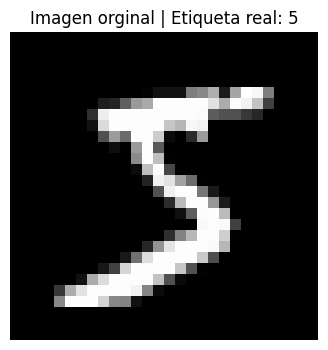

In [ ]:
# Mostramos la imagen original
indice_ejemplo=0

imagen= X_train[indice_ejemplo]

etiqueta= y_train[indice_ejemplo]

plt.figure(figsize=(4,4))

plt.imshow(imagen, cmap="gray")

plt.title(f"Imagen orginal | Etiqueta real: {etiqueta}")

plt.axis("off")
plt.show

In [ ]:
# Dividimos la imagen en patches
patch_size=7

patches=[]

for i in range(0, 28, patch_size):
  for j in range(0,28, patch_size):
    patch= imagen[i:i+patch_size, j:j+patch_size]
    patches.append(patch)

patches = np.array(patches)
print("Numero de patches:", len(patches))

Numero de patches: 16


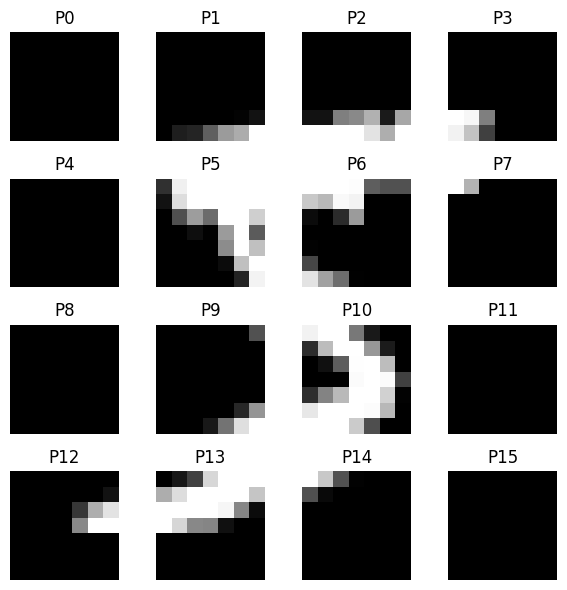

In [ ]:
# Vizualizamos los patches
fig, axes = plt.subplots(4 ,4, figsize=(6,6))

for idx, ax in enumerate(axes.flat):
  ax.imshow(patches[idx], cmap="gray")

  ax.axis("off")

  ax.set_title(f"P{idx}")
plt.tight_layout()
plt.show()

In [ ]:
#  Flatteing de patches

patches_flatten = patches.reshape(len(patches),-1)

print("Forma despues del flatten:", patches_flatten.shape)
print("\nPrimer patch convertido en vector:\n")
print(patches_flatten[0])

Forma despues del flatten: (16, 49)

Primer patch convertido en vector:

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [ ]:
# Pasar de patches a tokens visuales

num_tokens_visuales = patches_flatten.shape[0]

dimension_token_visual = patches_flatten.shape[1]

In [ ]:
# Funcion para crear patches en todo el dataset

def crear_patches(dataset, patch_size=7):
  imagenes_patches=[]
  for imagen in dataset:
    patches_imagen=[]
    for i in range(0, 28, patch_size):
      for j in range(0,28, patch_size):
        patch= imagen[i:i+patch_size, j:j+patch_size]
        patch= patch.flatten()
        patches_imagen.append(patch)
    imagenes_patches.append(patches_imagen)

  return np.array(imagenes_patches)

X_train_patches= crear_patches(X_train, patch_size=patch_size)
X_test_patches= crear_patches(X_test, patch_size=patch_size)

In [ ]:
# Proyeccion lineal y positional embeddings

num_patches = X_train_patches.shape[1]

patch_vector_dim = X_train_patches.shape[2]

embedding_dim= 64

position_embedding_layer = Embedding(
  input_dim=num_patches,
  output_dim=embedding_dim
)

In [ ]:
# Definimos bloque transformer
def transformer_block(x, num_heads=2, key_dim=32, ff_dim=128, dropout_rate=0.1):
  attention = MultiHeadAttention(
      num_heads=num_heads,
      key_dim=key_dim
  )(x,x)

  attention = Dropout(dropout_rate)(attention)

  x = x+ attention

  x=LayerNormalization(epsilon=1e-6)(x)

  ff= Dense(ff_dim, activation="relu")(x)
  ff= Dense(embedding_dim)(ff)

  ff= Dropout(dropout_rate)(ff)

  x = x + ff

  x= LayerNormalization(epsilon=1e-6)(x)

  return x

In [ ]:
# Construimos el vision transformer

inputs = Input(shape=(num_patches, patch_vector_dim))

x = Dense(embedding_dim)(inputs)

positions = tf.range(start=0, limit=num_patches, delta=1)

positional_embeddings = position_embedding_layer(positions)

x= x+ positional_embeddings

x = transformer_block(x)

x = transformer_block(x)

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)

x = Dropout(0.2)(x)

outputs = Dense(10, activation="softmax")(x)

modelo_vit = Model(inputs, outputs)

modelo_vit.compile(
    optimizer= Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_vit.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 16, 49)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16, 64)    │      3,200 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 16, 64)    │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 64)    │     16,640 │ add_5[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 16, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 16, 64)    │          0 │ add_5[0][0],      │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16, 64)    │      8,256 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 16, 64)    │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 16, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 16, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 16, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16, 64)    │      8,256 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 16, 64)    │          0 │ dense_11[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 74,954 (292.79 KB)

 Trainable params: 74,954 (292.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo

historial = modelo_vit.fit(
    X_train_patches,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128
)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 126ms/step - accuracy: 0.6295 - loss: 1.0856 - val_accuracy: 0.8087 - val_loss: 0.5726
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 131ms/step - accuracy: 0.8385 - loss: 0.5020 - val_accuracy: 0.9004 - val_loss: 0.3154
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 79s 124ms/step - accuracy: 0.8826 - loss: 0.3687 - val_accuracy: 0.9160 - val_loss: 0.2691
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 124ms/step - accuracy: 0.9035 - loss: 0.3055 - val_accuracy: 0.9118 - val_loss: 0.2786
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 120ms/step - accuracy: 0.9178 - loss: 0.2636 - val_accuracy: 0.9231 - val_loss: 0.2379


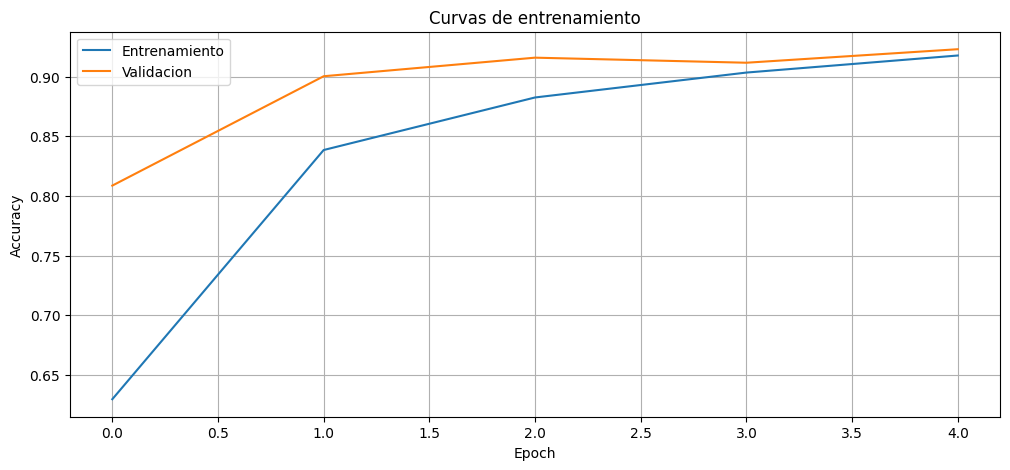

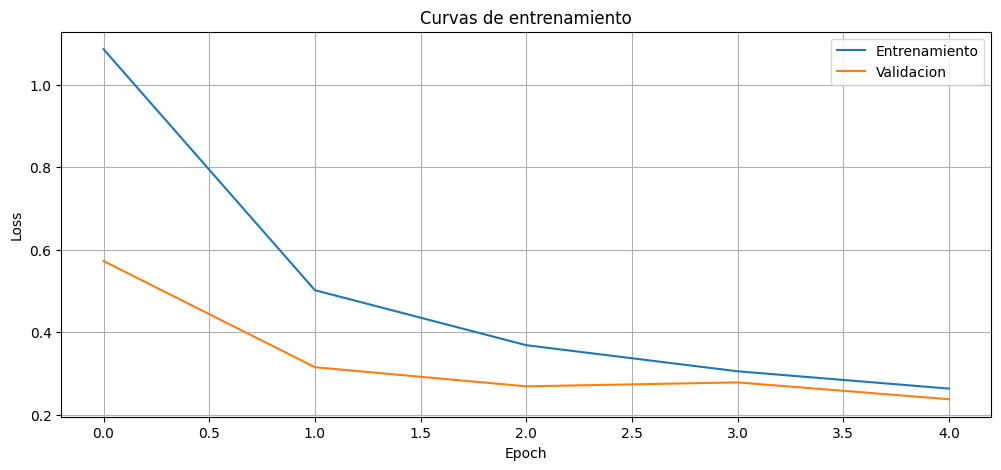

In [ ]:
# Graficamos curvas de entrenamiento

plt.figure(figsize=(12,5))
plt.plot(historial.history["accuracy"], label="Entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Validacion")
plt.title("Curvas de entrenamiento")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(historial.history["loss"], label="Entrenamiento")
plt.plot(historial.history["val_loss"], label="Validacion")
plt.title("Curvas de entrenamiento")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

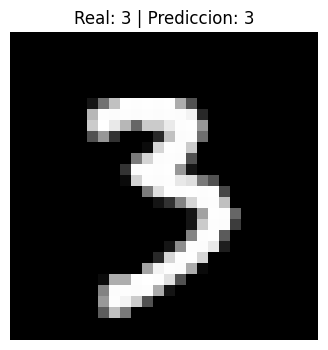

Distribucion softmax:
Clase 0: 0.0000
Clase 1: 0.0002
Clase 2: 0.0009
Clase 3: 0.9710
Clase 4: 0.0000
Clase 5: 0.0046
Clase 6: 0.0000
Clase 7: 0.0208
Clase 8: 0.0003
Clase 9: 0.0022


In [ ]:
# Prediccion

indice_test=30

imagen_test= X_test[indice_test]

label_real = y_test[indice_test]

patches_test =crear_patches(
    np.array([imagen_test]),
    patch_size=patch_size
)

prediccion = modelo_vit.predict(patches_test, verbose=0)

clase_predicha = np.argmax(prediccion[0])

plt.figure(figsize=(4,4))
plt.imshow(imagen_test, cmap="gray")
plt.title(f"Real: {label_real} | Prediccion: {clase_predicha}")
plt.axis("off")
plt.show()

print("Distribucion softmax:")
for clase, probabilidad in enumerate(prediccion[0]):
  print(f"Clase {clase}: {probabilidad:.4f}")

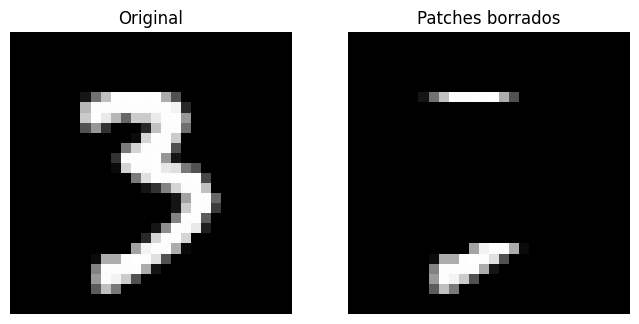

In [ ]:
# Ocultamos patches de una imagen

imagen_oculta = imagen_test.copy()

patches_visuales = []

for i in range(0, 28, patch_size):
  for j in range(0,28, patch_size):
    patches_visuales.append(imagen_oculta[i:i+patch_size, j:j+patch_size])

patches_visuales = np.array(patches_visuales)

patches_a_borrar = [5, 6, 9, 10]

patches_modificados = patches_visuales.copy()

for idx in patches_a_borrar:
  patches_modificados[idx]= np.zeros_like(patches_modificados[idx])

imagen_modificada= np.zeros((28,28))

indice_auxiliar = 0

for i in range(0, 28, patch_size):
  for j in range(0,28, patch_size):
    imagen_modificada[i:i+patch_size, j:j+patch_size]= patches_modificados[indice_auxiliar]
    indice_auxiliar +=1

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].imshow(imagen_test, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(imagen_modificada, cmap="gray")
ax[1].set_title("Patches borrados")
ax[1].axis("off")

plt.show()

In [ ]:
# Predicicon con patches ocultos

patches_modificados_modelo = crear_patches(
    np.array([imagen_modificada]),
    patch_size=patch_size
)

prediccion_modificada = modelo_vit.predict(
    patches_modificados_modelo,
    verbose=0
)

clase_predicha_modificada = np.argmax(prediccion_modificada[0])

print("Clase real:", label_real)
print("Prediccion original:", clase_predicha)
print("Prediccion con patches ocultos:", clase_predicha_modificada)

print("\nComparacion de pprobabilidades:")
for clase in range(10):
  print(f"Clase {clase}:"
  f"Original={prediccion[0][clase]:.4f}|"
  f"Modificada= {prediccion_modificada[0][clase]:.4f}")

Clase real: 3
Prediccion original: 3
Prediccion con patches ocultos: 5

Comparacion de pprobabilidades:
Clase 0:Original=0.0000|Modificada= 0.0000
Clase 1:Original=0.0002|Modificada= 0.0636
Clase 2:Original=0.0009|Modificada= 0.0224
Clase 3:Original=0.9710|Modificada= 0.0092
Clase 4:Original=0.0000|Modificada= 0.0000
Clase 5:Original=0.0046|Modificada= 0.8804
Clase 6:Original=0.0000|Modificada= 0.0000
Clase 7:Original=0.0208|Modificada= 0.0241
Clase 8:Original=0.0003|Modificada= 0.0001
Clase 9:Original=0.0022|Modificada= 0.0002
